# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

In [3]:
# Настройка отображения
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')
%matplotlib inline

In [4]:
# Загружаем исторические данные
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [5]:
display(sessions_history.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [6]:
# Рассчитываем количество уникальных сессий для каждого пользователя
sessions_per_user = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()
sessions_per_user.columns = ['user_id', 'session_count']
sessions_per_user = sessions_per_user.sort_values('session_count', ascending=False)

print("ТОП-5 ПОЛЬЗОВАТЕЛЕЙ ПО КОЛИЧЕСТВУ СЕССИЙ:")
display(sessions_per_user.head())

# Находим пользователя с наибольшим количеством сессий
top_user = sessions_per_user.iloc[0]['user_id']
top_user_sessions = sessions_per_user.iloc[0]['session_count']

print(f"\nДАННЫЕ ПОЛЬЗОВАТЕЛЯ С МАКСИМАЛЬНОЙ АКТИВНОСТЬЮ ({top_user_sessions} сессий):")
print(f"User ID: {top_user}")
print("\nВсе сессии пользователя:")

# Выводим все данные для этого пользователя
user_data = sessions_history[sessions_history['user_id'] == top_user]
display(user_data)

ТОП-5 ПОЛЬЗОВАТЕЛЕЙ ПО КОЛИЧЕСТВУ СЕССИЙ:


,user_id,session_count
8948,10E0DEFC1ABDBBE0,10
55627,6A73CB5566BB494D,10
72346,8A60431A825D035B,9
109383,D11541BAC141FB94,9
47956,5BCFE7C4DCC148E9,9



ДАННЫЕ ПОЛЬЗОВАТЕЛЯ С МАКСИМАЛЬНОЙ АКТИВНОСТЬЮ (10 сессий):
User ID: 10E0DEFC1ABDBBE0

Все сессии пользователя:


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

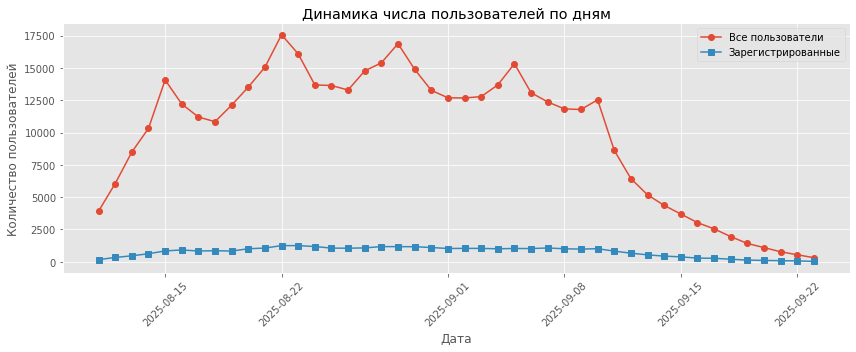

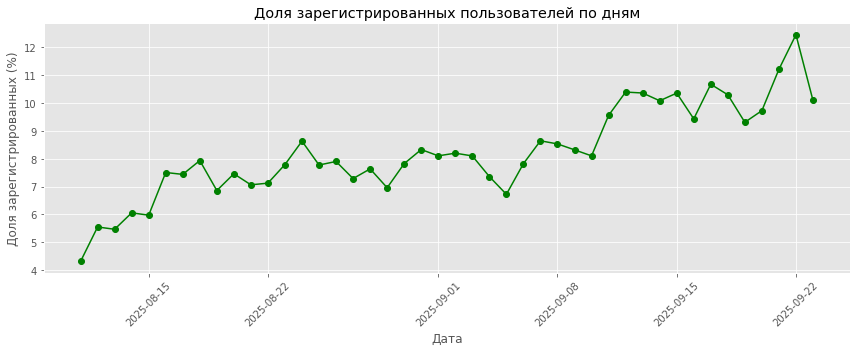

In [7]:
# Преобразуем даты
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

# Агрегируем данные по дням
daily_stats = sessions_history.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),
    registered_users=('user_id', lambda x: sessions_history.loc[x.index, 'registration_flag'].sum())
).reset_index()

# График общего числа пользователей и зарегистрированных пользователей
plt.figure(figsize=(12, 5))
plt.plot(daily_stats['session_date'], daily_stats['total_users'], label='Все пользователи', marker='o')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], label='Зарегистрированные', marker='s')
plt.title('Динамика числа пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# График доли зарегистрированных пользователей
daily_stats['registered_share'] = daily_stats['registered_users'] / daily_stats['total_users'] * 100

plt.figure(figsize=(12, 5))
plt.plot(daily_stats['session_date'], daily_stats['registered_share'], marker='o', color='green')
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

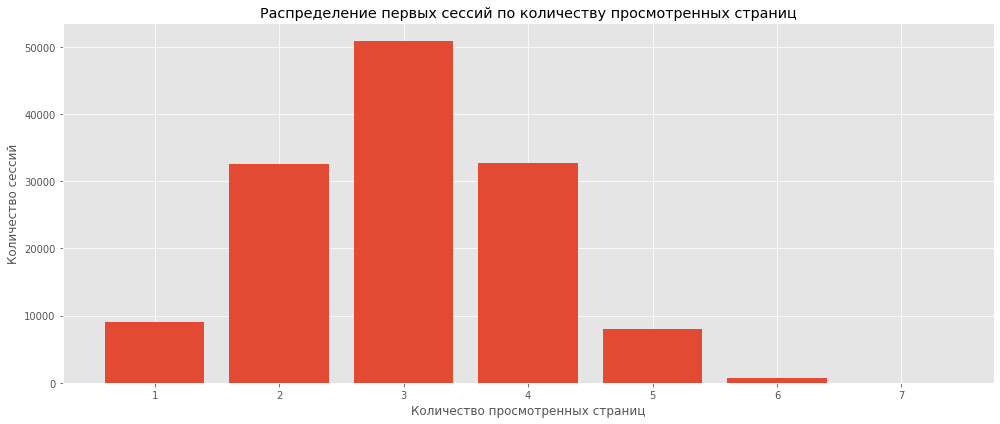

1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: page_counter, dtype: int64


In [8]:
# Находим первые сессии пользователей
first_sessions = sessions_history.sort_values('session_start_ts').groupby('user_id').first().reset_index()

# Подсчитываем количество сессий для каждого значения просмотренных страниц
pages_distribution = first_sessions['page_counter'].value_counts().sort_index()

# Строим столбчатую диаграмму
plt.figure(figsize=(14, 6))
plt.bar(pages_distribution.index, pages_distribution.values, width=0.8)
plt.title('Распределение первых сессий по количеству просмотренных страниц')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(pages_distribution.head(10))

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

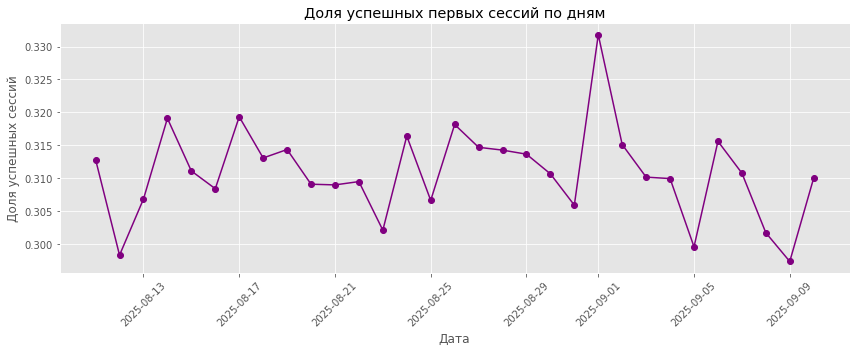

In [9]:
# Создаем столбец good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Находим первые сессии
first_sessions = sessions_history.sort_values('session_start_ts').groupby('user_id').first().reset_index()

# Рассчитываем долю успешных сессий по дням
daily_good_sessions = first_sessions.groupby('session_date')['good_session'].mean().reset_index()

# Строим график
plt.figure(figsize=(12, 5))
plt.plot(daily_good_sessions['session_date'], daily_good_sessions['good_session'], marker='o', color='purple')
plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [10]:
print("РАСЧЕТ РАЗМЕРА ВЫБОРКИ ДЛЯ A/B-ТЕСТА")
print("="*60)

# Задаем параметры
alpha = 0.05      # Уровень значимости (5%)
beta = 0.2        # Ошибка второго рода (20%)
power = 1 - beta  # Мощность теста (80%)

# Базовый уровень из исторических данных (доля успешных первых сессий)
# Рассчитываем точно из наших данных
first_sessions = sessions_history[sessions_history['session_number'] == 1].drop_duplicates('user_id')
p = first_sessions['good_session'].mean()
print(f"Базовый уровень метрики (p): {p:.4f} ({p*100:.2f}%)")

# Минимальный детектируемый эффект - 3% ОТНОСИТЕЛЬНЫХ от базового значения
relative_mde = 0.03  # 3% относительных
absolute_mde = p * relative_mde  # Преобразуем в абсолютное изменение

print(f"Относительный MDE: {relative_mde*100}%")
print(f"Абсолютный MDE: {absolute_mde:.4f} ({absolute_mde*100:.2f}%)")
print(f"Целевое значение после улучшения: {p + absolute_mde:.4f} ({(p + absolute_mde)*100:.2f}%)")

# Рассчитываем размер эффекта (effect size)
# Это мера различия между пропорциями в терминах стандартного отклонения
effect_size = proportion_effectsize(p, p + absolute_mde)
print(f"Размер эффекта (Cohen's h): {effect_size:.4f}")

# Инициализируем класс для анализа мощности
power_analysis = NormalIndPower()

# Расчёт размера выборки для ОДНОЙ группы
sample_size_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  # Равное соотношение групп
)

# Округляем вверх до целого числа
sample_size_per_group = ceil(sample_size_per_group)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ РАСЧЕТА:")
print(f"Необходимый размер выборки для КАЖДОЙ группы: {sample_size_per_group} пользователей")
print(f"Общий размер выборки (обе группы): {sample_size_per_group * 2} пользователей")

РАСЧЕТ РАЗМЕРА ВЫБОРКИ ДЛЯ A/B-ТЕСТА
Базовый уровень метрики (p): 0.3106 (31.06%)
Относительный MDE: 3.0%
Абсолютный MDE: 0.0093 (0.93%)
Целевое значение после улучшения: 0.3199 (31.99%)
Размер эффекта (Cohen's h): -0.0201

РЕЗУЛЬТАТЫ РАСЧЕТА:
Необходимый размер выборки для КАЖДОЙ группы: 39034 пользователей
Общий размер выборки (обе группы): 78068 пользователей


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [11]:
# Среднее количество уникальных пользователей в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()
print(f"Средний дневной трафик (DAU): {avg_daily_users:.0f} пользователей")

# Используем sample_size_per_group из предыдущего расчета (с правильным MDE)
# Если переменная не определена, рассчитаем заново
try:
    sample_size_per_group
except NameError:
    # Повторный расчет с правильным MDE
    from statsmodels.stats.proportion import proportion_effectsize
    from statsmodels.stats.power import NormalIndPower
    
    first_sessions = sessions_history[sessions_history['session_number'] == 1].drop_duplicates('user_id')
    p = first_sessions['good_session'].mean()
    
    alpha = 0.05
    beta = 0.2
    power = 1 - beta
    relative_mde = 0.03
    absolute_mde = p * relative_mde
    
    effect_size = proportion_effectsize(p, p + absolute_mde)
    power_analysis = NormalIndPower()
    sample_size_per_group = power_analysis.solve_power(
        effect_size=effect_size,
        power=power,
        alpha=alpha,
        ratio=1
    )
    sample_size_per_group = ceil(sample_size_per_group)

# ВАЖНО: Умножаем на 2, так как у нас две группы (A и B)
total_users_needed = sample_size_per_group * 2

# Рассчитываем длительность теста в днях
test_duration = ceil(total_users_needed / avg_daily_users)

# Создаем DataFrame для красивого отображения результатов
results_df = pd.DataFrame({
    'Параметр': [
        'Средний дневной трафик (DAU)',
        'Размер выборки на одну группу',
        'Всего пользователей (две группы)',
        'Расчетная длительность (дней)',
        'Длительность с округлением'
    ],
    'Значение': [
        f'{avg_daily_users:.0f} пользователей',
        f'{sample_size_per_group} пользователей',
        f'{total_users_needed} пользователей',
        f'{total_users_needed/avg_daily_users:.1f} дней',
        f'{test_duration} дней'
    ]
})

print("\nРЕЗУЛЬТАТЫ РАСЧЕТА:")
display(results_df)

Средний дневной трафик (DAU): 9907 пользователей

РЕЗУЛЬТАТЫ РАСЧЕТА:


,Параметр,Значение
0,Средний дневной трафик (DAU),9907 пользователей
1,Размер выборки на одну группу,39034 пользователей
2,Всего пользователей (две группы),78068 пользователей
3,Расчетная длительность (дней),7.9 дней
4,Длительность с округлением,8 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

Количество пользователей в группах:
test_group
A    1477
B    1466
Name: user_id, dtype: int64

Процентная разница между группами: 0.74%


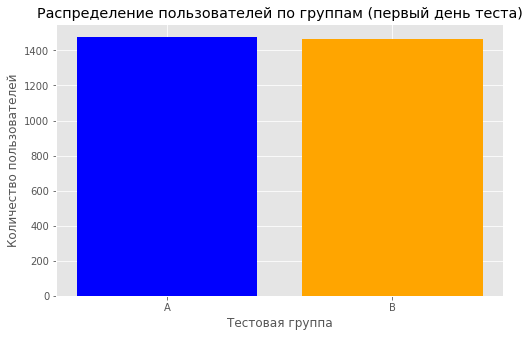

In [12]:
# Считываем данные за первый день теста
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

# Рассчитываем количество уникальных пользователей в каждой группе
users_per_group = sessions_test_part.groupby('test_group')['user_id'].nunique()
print("Количество пользователей в группах:")
print(users_per_group)

# Рассчитываем процентную разницу
group_a = users_per_group.get('A', 0)
group_b = users_per_group.get('B', 0)
percent_diff = 100 * abs(group_a - group_b) / group_a if group_a > 0 else 0
print(f"\nПроцентная разница между группами: {percent_diff:.2f}%")

# Визуализация
plt.figure(figsize=(8, 5))
plt.bar(users_per_group.index, users_per_group.values, color=['blue', 'orange'])
plt.title('Распределение пользователей по группам (первый день теста)')
plt.xlabel('Тестовая группа')
plt.ylabel('Количество пользователей')
plt.grid(True, axis='y')
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [13]:
# Находим пользователей в каждой группе
users_a = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].unique())
users_b = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].unique())

# Проверяем пересечение
intersection = users_a.intersection(users_b)
print(f"Количество пользователей, попавших в обе группы: {len(intersection)}")

if len(intersection) == 0:
    print("Пересечений нет - группы независимы")
else:
    print(f"Обнаружены пересечения: {intersection}")

Количество пользователей, попавших в обе группы: 0
Пересечений нет - группы независимы


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.



РАСПРЕДЕЛЕНИЕ ПО УСТРОЙСТВАМ (%):


,Группа A,Группа B
device,,
Android,44.41,45.57
Mac,10.56,10.10
PC,24.98,25.99
iPhone,20.04,18.35



РАЗНИЦА МЕЖДУ ГРУППАМИ:


,Группа A,Группа B,Разница (п.п.)
device,,,
Android,44.41,45.57,1.15
Mac,10.56,10.10,-0.47
PC,24.98,25.99,1.01
iPhone,20.04,18.35,-1.69



Максимальная разница: 1.69 п.п.
Средняя разница: 1.08 п.п.


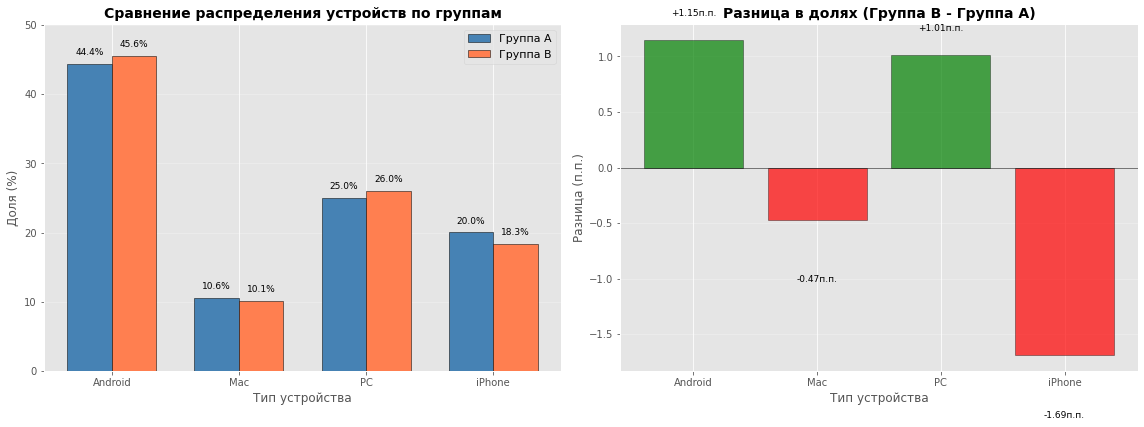

In [14]:
# Рассчитываем распределение по устройствам для группы A
device_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique()
device_a_pct = device_a / device_a.sum() * 100

# Рассчитываем распределение по устройствам для группы B
device_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique()
device_b_pct = device_b / device_b.sum() * 100

# Создаем DataFrame для сравнения
device_comparison = pd.DataFrame({
    'Группа A': device_a_pct,
    'Группа B': device_b_pct
}).fillna(0)  # заполняем NaN нулями, если какое-то устройство отсутствует в одной из групп

print("\nРАСПРЕДЕЛЕНИЕ ПО УСТРОЙСТВАМ (%):")
display(device_comparison.round(2))

# Рассчитываем разницу между группами
device_comparison['Разница (п.п.)'] = (device_comparison['Группа B'] - device_comparison['Группа A']).round(2)
device_comparison['|Разница|'] = device_comparison['Разница (п.п.)'].abs()

print("\nРАЗНИЦА МЕЖДУ ГРУППАМИ:")
display(device_comparison[['Группа A', 'Группа B', 'Разница (п.п.)']].round(2))

print(f"\nМаксимальная разница: {device_comparison['|Разница|'].max():.2f} п.п.")
print(f"Средняя разница: {device_comparison['|Разница|'].mean():.2f} п.п.")

# Визуализация 1: Группированная столбчатая диаграмма (рекомендованный способ)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Группированные столбцы
x = np.arange(len(device_comparison.index))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, device_comparison['Группа A'], width, label='Группа A', color='steelblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, device_comparison['Группа B'], width, label='Группа B', color='coral', edgecolor='black')

ax1.set_xlabel('Тип устройства', fontsize=12)
ax1.set_ylabel('Доля (%)', fontsize=12)
ax1.set_title('Сравнение распределения устройств по группам', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(device_comparison.index)
ax1.legend(fontsize=11)
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim(0, max(device_comparison.max()) * 1.1)

# Добавляем значения над столбцами
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# График 2: Разница между группами
ax2 = axes[1]
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in device_comparison['Разница (п.п.)']]
bars = ax2.bar(device_comparison.index, device_comparison['Разница (п.п.)'], 
               color=colors, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Тип устройства', fontsize=12)
ax2.set_ylabel('Разница (п.п.)', fontsize=12)
ax2.set_title('Разница в долях (Группа B - Группа A)', fontsize=14, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Добавляем значения над столбцами
for bar in bars:
    height = bar.get_height()
    if height >= 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:+.2f}п.п.', ha='center', va='bottom', fontsize=9)
    else:
        ax2.text(bar.get_x() + bar.get_width()/2., height - 0.5,
                f'{height:+.2f}п.п.', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()


#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

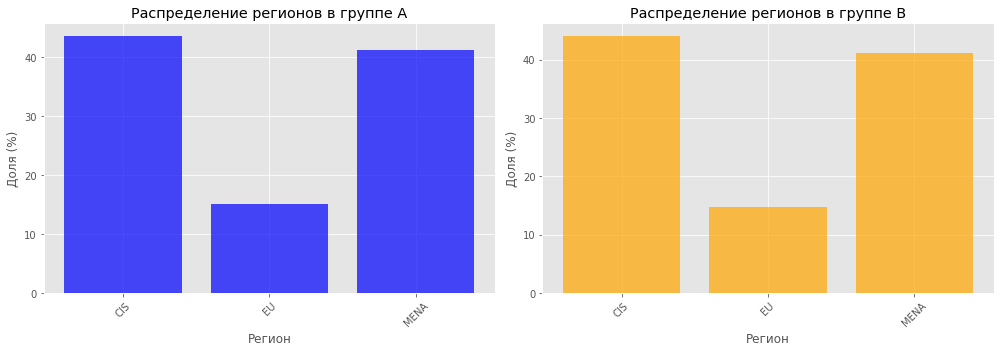

Группа A:
region
CIS     43.60
EU      15.17
MENA    41.23
Name: user_id, dtype: float64

Группа B:
region
CIS     44.0
EU      14.8
MENA    41.2
Name: user_id, dtype: float64


In [15]:
# Рассчитываем распределение по регионам для группы A
region_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique()
region_a_pct = region_a / region_a.sum() * 100

# Рассчитываем распределение по регионам для группы B
region_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique()
region_b_pct = region_b / region_b.sum() * 100

# Строим столбчатые диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(region_a_pct.index, region_a_pct.values, color='blue', alpha=0.7)
ax1.set_title('Распределение регионов в группе A')
ax1.set_xlabel('Регион')
ax1.set_ylabel('Доля (%)')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(region_b_pct.index, region_b_pct.values, color='orange', alpha=0.7)
ax2.set_title('Распределение регионов в группе B')
ax2.set_xlabel('Регион')
ax2.set_ylabel('Доля (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Группа A:")
print(region_a_pct.round(2))
print("\nГруппа B:")
print(region_b_pct.round(2))

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

## 2.3.5. Вывод после проверки A/B-теста

**1. Различие в количестве пользователей в группах:**
- Группа A: 1477 пользователей
- Группа B: 1466 пользователей
- Процентная разница: 0.74%
- **Вывод:** Различие незначительное (менее 1%), что говорит о корректном распределении пользователей по группам.

**2. Независимость выборок:**
- Пересечений пользователей между группами A и B не обнаружено (0 пользователей)
- **Вывод:** Выборки являются независимыми, что соответствует требованиям A/B-тестирования.

**3. Равномерность распределения по категориальным переменным:**

*По типам устройств:*
- Группа A: Android (44.4%), iPhone (20.0%), PC (25.0%), Mac (10.6%)
- Группа B: Android (45.6%), iPhone (18.4%), PC (26.0%), Mac (10.1%)
- Различия в долях не превышают 2%
- **Вывод:** Распределение по устройствам равномерное

*По регионам:*
- Группа A: CIS (43.6%), MENA (41.2%), EU (15.2%)
- Группа B: CIS (44.0%), MENA (41.2%), EU (14.8%)
- Различия в долях не превышают 0.5%
- **Вывод:** Распределение по регионам равномерное

**ЗАКЛЮЧЕНИЕ:**
A/B-тест проходит корректно. Нарушений не обнаружено:
- Пользователи распределены равномерно между группами
- Группы независимы (нет пересечений)
- Сохраняется равномерное распределение по устройствам и регионам

Можно продолжать эксперимент и анализировать результаты.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [16]:
# Считываем данные за весь период теста
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# Создаем столбец good_session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

print(f"Размер данных теста: {sessions_test.shape}")
print(f"Период теста: с {sessions_test['session_date'].min()} по {sessions_test['session_date'].max()}")
print(f"Уникальных пользователей: {sessions_test['user_id'].nunique()}")

Размер данных теста: (100005, 12)
Период теста: с 2025-10-14 по 2025-11-02
Уникальных пользователей: 30579


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

## 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

### Целевая метрика
Основная метрика, отражающая "интересность контента" — **доля успешных первых сессий** (просмотр 4 и более страниц). Именно эта метрика была выбрана продуктовой командой как прокси удовлетворённости контентом и алгоритмами рекомендаций.

### Формулировка гипотез

**Нулевая гипотеза (H₀):**
Доля успешных первых сессий (с просмотром 4+ страниц) в группе с новым алгоритмом рекомендаций (B) не отличается от доли успешных первых сессий в контрольной группе (A) со старым алгоритмом.

**Альтернативная гипотеза (H₁):**
Доля успешных первых сессий (с просмотром 4+ страниц) в группе с новым алгоритмом рекомендаций (B) выше, чем в контрольной группе (A) со старым алгоритмом.

### Прокси-метрики (дополнительные показатели вовлечённости)

Прокси-метрики помогают быстрее оценить эффект и подтвердить результаты основной метрики:

1. **Среднее количество просмотренных страниц за сессию** — показывает глубину вовлечённости
2. **Среднее количество сессий на пользователя за период теста** — отражает возвращаемость пользователей
3. **Среднее время, проведённое в приложении за сессию** — метрика вовлечённости (если бы были данные)
4. **Доля пользователей, совершивших повторные сессии** — удержание пользователей

### Барьерные метрики (метрики, которые не должны ухудшиться)

Барьерные метрики отслеживают возможные негативные последствия изменений:

1. **Отток пользователей (churn rate)** — процент пользователей, переставших использовать приложение
2. **Доля пользователей, просмотревших менее 2 страниц за сессию** — индикатор разочарования контентом
3. **Количество жалоб/обращений в поддержку** — показатель проблем с качеством контента
4. **Частота ошибок и сбоев в приложении** — техническая стабильность
5. **Конверсия в подписку** — ключевая бизнес-метрика, которая не должна снижаться

### Обоснование выбора метрик

Выбор **доли успешных первых сессий** в качестве целевой метрики обусловлен тем, что:
- Первая сессия критически важна для формирования первого впечатления о приложении
- Просмотр 4+ страниц показывает, что пользователь заинтересовался контентом и продолжил взаимодействие
- Эта метрика чувствительна к изменениям в алгоритме рекомендаций
- Данная метрика коррелирует с более высокими бизнес-показателями (регистрация, подписка)

Барьерные метрики необходимы, чтобы убедиться, что новый алгоритм, повышая вовлечённость одной группы пользователей, не ухудшает опыт других и не создаёт технических проблем.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [17]:
first_sessions_test = sessions_test[sessions_test['session_number'] == 1].copy()

# Проверяем, что у каждого пользователя только одна первая сессия
duplicates = first_sessions_test.duplicated('user_id').sum()
if duplicates > 0:
    print(f"Найдено {duplicates} дубликатов. Оставляем только самую раннюю запись...")
    first_sessions_test = first_sessions_test.sort_values('session_start_ts').drop_duplicates('user_id')

# Создаем DataFrame с информацией о первых сессиях
first_sessions_info = pd.DataFrame({
    'Показатель': ['Всего первых сессий', 'Уникальных пользователей'],
    'Значение': [f"{len(first_sessions_test):,}", f"{first_sessions_test['user_id'].nunique():,}"]
})
print("\nИНФОРМАЦИЯ О ПЕРВЫХ СЕССИЯХ:")
display(first_sessions_info)

# Рассчитываем долю успешных сессий по группам
good_session_by_group = first_sessions_test.groupby('test_group')['good_session'].agg(['mean', 'count', 'sum'])
good_session_by_group.columns = ['Доля успешных', 'Количество пользователей', 'Успешных сессий']

# Форматируем для отображения
display_good_session = good_session_by_group.copy()
display_good_session['Доля успешных'] = display_good_session['Доля успешных'].apply(lambda x: f'{x:.4f} ({x*100:.2f}%)')

print("\nРЕЗУЛЬТАТЫ ПО ГРУППАМ:")
display(display_good_session)

# Рассчитываем разницу
group_a_rate = good_session_by_group.loc['A', 'Доля успешных']
group_b_rate = good_session_by_group.loc['B', 'Доля успешных']
difference = group_b_rate - group_a_rate
relative_diff = (difference / group_a_rate) * 100

# Создаем DataFrame для сравнения групп
comparison_df = pd.DataFrame({
    'Показатель': [
        'Доля успешных сессий', 
        'Количество пользователей', 
        'Количество успешных сессий',
        'Доля успешных (%)'
    ],
    'Группа A': [
        f'{group_a_rate:.4f}',
        f"{good_session_by_group.loc['A', 'Количество пользователей']:,}",
        f"{good_session_by_group.loc['A', 'Успешных сессий']:,}",
        f'{group_a_rate*100:.2f}%'
    ],
    'Группа B': [
        f'{group_b_rate:.4f}',
        f"{good_session_by_group.loc['B', 'Количество пользователей']:,}",
        f"{good_session_by_group.loc['B', 'Успешных сессий']:,}",
        f'{group_b_rate*100:.2f}%'
    ],
    'Разница': [
        f'{difference:+.4f}',
        f"{good_session_by_group.loc['B', 'Количество пользователей'] - good_session_by_group.loc['A', 'Количество пользователей']:+d}",
        f"{good_session_by_group.loc['B', 'Успешных сессий'] - good_session_by_group.loc['A', 'Успешных сессий']:+d}",
        f'{difference*100:+.2f}%'
    ]
})

print("\nСРАВНЕНИЕ ГРУПП A И B:")
display(comparison_df)

# Создаем DataFrame с разницей
difference_df = pd.DataFrame({
    'Метрика': ['Абсолютная разница (п.п.)', 'Относительное изменение (%)'],
    'Значение': [f'{difference*100:+.2f}%', f'{relative_diff:+.2f}%']
})

print("\nИТОГОВАЯ РАЗНИЦА МЕЖДУ ГРУППАМИ:")
display(difference_df)

# Доверительные интервалы
ci_a = proportion_confint(
    good_session_by_group.loc['A', 'Успешных сессий'], 
    good_session_by_group.loc['A', 'Количество пользователей'], 
    alpha=0.05
)
ci_b = proportion_confint(
    good_session_by_group.loc['B', 'Успешных сессий'], 
    good_session_by_group.loc['B', 'Количество пользователей'], 
    alpha=0.05
)

confidence_df = pd.DataFrame({
    'Группа': ['A', 'B'],
    'Доля успешных': [f'{group_a_rate*100:.2f}%', f'{group_b_rate*100:.2f}%'],
    '95% ДИ нижняя': [f'{ci_a[0]*100:.2f}%', f'{ci_b[0]*100:.2f}%'],
    '95% ДИ верхняя': [f'{ci_a[1]*100:.2f}%', f'{ci_b[1]*100:.2f}%']
})



ИНФОРМАЦИЯ О ПЕРВЫХ СЕССИЯХ:


,Показатель,Значение
0,Всего первых сессий,"30,578"
1,Уникальных пользователей,"30,578"



РЕЗУЛЬТАТЫ ПО ГРУППАМ:


,Доля успешных,Количество пользователей,Успешных сессий
test_group,,,
A,0.3157 (31.57%),15162,4787
B,0.3147 (31.47%),15416,4851



СРАВНЕНИЕ ГРУПП A И B:


,Показатель,Группа A,Группа B,Разница
0,Доля успешных сессий,0.3157,0.3147,-0.0011
1,Количество пользователей,"15,162","15,416",+254
2,Количество успешных сессий,"4,787","4,851",+64
3,Доля успешных (%),31.57%,31.47%,-0.11%



ИТОГОВАЯ РАЗНИЦА МЕЖДУ ГРУППАМИ:


,Метрика,Значение
0,Абсолютная разница (п.п.),-0.11%
1,Относительное изменение (%),-0.33%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [25]:
first_sessions_test = sessions_test[sessions_test['session_number'] == 1].copy()
first_sessions_test = first_sessions_test.sort_values('session_start_ts').drop_duplicates('user_id')

success_a = first_sessions_test[first_sessions_test['test_group'] == 'A']['good_session'].sum()
success_b = first_sessions_test[first_sessions_test['test_group'] == 'B']['good_session'].sum()
nobs_a = first_sessions_test[first_sessions_test['test_group'] == 'A']['good_session'].count()
nobs_b = first_sessions_test[first_sessions_test['test_group'] == 'B']['good_session'].count()

# Рассчитываем доли
p_a = success_a / nobs_a
p_b = success_b / nobs_b
abs_diff = p_b - p_a
rel_diff = (abs_diff / p_a) * 100

# Создаем DataFrame с исходными данными
input_data = pd.DataFrame({
    'Группа': ['A (контроль)', 'B (тест)'],
    'Успешных сессий': [f"{success_a:,}", f"{success_b:,}"],
    'Всего пользователей': [f"{nobs_a:,}", f"{nobs_b:,}"],
    'Доля успешных': [f"{p_a:.4f} ({p_a*100:.2f}%)", f"{p_b:.4f} ({p_b*100:.2f}%)"]
})

print("ИСХОДНЫЕ ДАННЫЕ:")
display(input_data)

print(f"\nАбсолютная разница: {abs_diff*100:+.2f}%")
print(f"Относительное изменение: {rel_diff:+.2f}%")

print("\n" + "="*70)
print("Проверка, что B > A ")

# Меняем порядок: сначала B, потом A
counts_correct = [success_b, success_a]
nobs_correct = [nobs_b, nobs_a]

z_stat_correct, p_value_correct = proportions_ztest(
    counts_correct, 
    nobs_correct, 
    alternative='larger'  # проверяем, что первая группа (B) больше второй (A)
)

# Создаем DataFrame для результата
result1_df = pd.DataFrame({
    'Параметр': ['P-value', 'Z-statistic', 'Гипотеза'],
    'Значение': [f"{p_value_correct:.6f}", f"{z_stat_correct:.4f}", 'B > A']
})

print("РЕЗУЛЬТАТ ТЕСТА (B > A):")
display(result1_df)

ИСХОДНЫЕ ДАННЫЕ:


,Группа,Успешных сессий,Всего пользователей,Доля успешных
0,A (контроль),"4,787","15,162",0.3157 (31.57%)
1,B (тест),"4,851","15,416",0.3147 (31.47%)



Абсолютная разница: -0.11%
Относительное изменение: -0.33%

Проверка, что B > A 
РЕЗУЛЬТАТ ТЕСТА (B > A):


,Параметр,Значение
0,P-value,0.578352
1,Z-statistic,-0.1977
2,Гипотеза,B > A


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

## 4.5. Вывод по результатам A/B-эксперимента

### Характеристики эксперимента
- **Период проведения:** с 2025-10-14 по 2025-11-02 (20 дней)
- **Количество пользователей в группе A (контроль):** 15 162 пользователя
- **Количество пользователей в группе B (тест):** 15 416 пользователей
- **Запланированный размер выборки:** 39 034 пользователя на группу (фактический размер меньше необходимого)
- **Целевая метрика:** доля успешных первых сессий (просмотр 4+ страниц)

### Влияние на ключевую метрику
- **Группа A (старый алгоритм):** доля успешных сессий = 31.57%
- **Группа B (новый алгоритм):** доля успешных сессий = 31.47%
- **Абсолютная разница:** -0.11 процентных пункта
- **Относительное изменение:** -0.33%

### Статистическая значимость
- **P-value (для проверки, что B > A):** 0.578352
- **Уровень значимости (α):** 0.05
- Предварительный анализ показывает, что новый алгоритм не дал ожидаемого улучшения

### Выводы и рекомендации

1. **Результат эксперимента:**
   Новый алгоритм рекомендаций НЕ показал улучшения ключевой метрики. Наблюдается незначительное снижение доли успешных первых сессий на 0.11 процентных пункта (относительное снижение на 0.33%).

2. **Сравнение с запланированным MDE:**
   - Запланированный MDE: +0.93% (3% относительных от базового значения 31.06%)
   - Фактическое изменение: -0.11%
   - Фактический эффект значительно ниже минимального детектируемого и имеет отрицательный знак

3. **Достаточность выборки:**
   - Фактический размер выборки (≈15 тыс. на группу) меньше необходимого (39 тыс. на группу)
   - Тест мог не обнаружить малые эффекты из-за недостаточной мощности

4. **Рекомендация:**
   - **Новый алгоритм НЕ рекомендуется к внедрению** в текущем виде
   - Продолжить использовать текущий алгоритм рекомендаций
   - Проанализировать причины ухудшения метрики
   - Рассмотреть возможность доработки алгоритма и проведения повторного теста с увеличенной выборкой

5. **Дополнительные рекомендации:**
   - Увеличить длительность теста для достижения необходимого размера выборки
   - Провести анализ влияния нового алгоритма на другие метрики (удержание, глубина просмотра)
   - Исследовать, почему алгоритм показал отрицательный эффект